# Optimal Transport in linear Independent Component Analysis
#### In this notebook, we demonstrate why $W_2$ is a better choice for OT-ICA than $W_1$ distance.

---

### Experiment Overview
This experiment evaluates the suitability of different Wasserstein distances as objective functions for ICA. By rotating a whitened 2D dataset through $180^\circ$, we compare the **optimization landscapes** and **gradient stability** of $W_1$ versus $W_2$.

### Key Objectives:
* **Landscape Smoothness:** Visualize which metric provides a smoother, more reliable path toward the independent components (the peaks).
* **Gradient Reliability:** Analyze numerical derivatives to determine which metric offers a cleaner signal for gradient-based optimization solvers.

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from wasserstein_ica import WassersteinICA

In [8]:
# Define a consistent Thesis Theme
def set_thesis_theme():
    # Academic, colorblind-friendly palette
    # Blue, Orange, Green, Red, Purple, Brown
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    
    mpl.rcParams.update({
        # Figure and Layout
        'figure.figsize': (8, 5),
        'figure.dpi': 300,            # High resolution for print
        'axes.prop_cycle': mpl.cycler(color=thesis_colors),
        
        # Grid lines (light and unobtrusive)
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,       # Grid goes behind data
        
        # Spines (remove top and right borders for a cleaner look)
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Fonts and Text
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        
        # Legends
        'legend.frameon': False,      # No box around the legend
        'legend.fontsize': 10,
        
        # Lines
        'lines.linewidth': 2.0
    })

# Run this before plotting
set_thesis_theme()

In [10]:
# 1. Data Simulation
np.random.seed(42)

# Simulate data (using df=4 as a representative example)
n_samples = 5000
df = 4 
A = np.array([[2.0, 0.0], [0.0, 0.5]])
S = np.random.standard_t(df=df, size=(2, n_samples))
X = A @ S
X_torch = torch.tensor(X, dtype=torch.float32)

In [11]:
# 2. INITIALIZE ICA OBJECT (Required for the second plot)
ica = WassersteinICA(X_torch)
ica.whiten()

# 3. SECOND PLOT CODE (Your original logic)
n_grid_dense = 500
thetas_dense = torch.linspace(0, np.pi, steps=n_grid_dense, device=ica.X_white.device)
ws_dense = torch.stack([torch.cos(thetas_dense), torch.sin(thetas_dense)], dim=1)

In [12]:
w1_raw = []
w2_sq_raw = []

for w in ws_dense:
    w_norm = w / torch.norm(w)
    w1_raw.append(ica.wasserstein1_distance(w_norm).item())
    w2_sq_raw.append(ica.wasserstein2_distance(w_norm).item())

w1_raw = np.array(w1_raw)
w2_sq_raw = np.array(w2_sq_raw)
thetas_np = thetas_dense.cpu().numpy()

grad_w1 = np.gradient(w1_raw, thetas_np)
grad_w2 = np.gradient(w2_sq_raw, thetas_np)

grad_w1_norm = grad_w1 / np.max(np.abs(grad_w1))
grad_w2_norm = grad_w2 / np.max(np.abs(grad_w2))

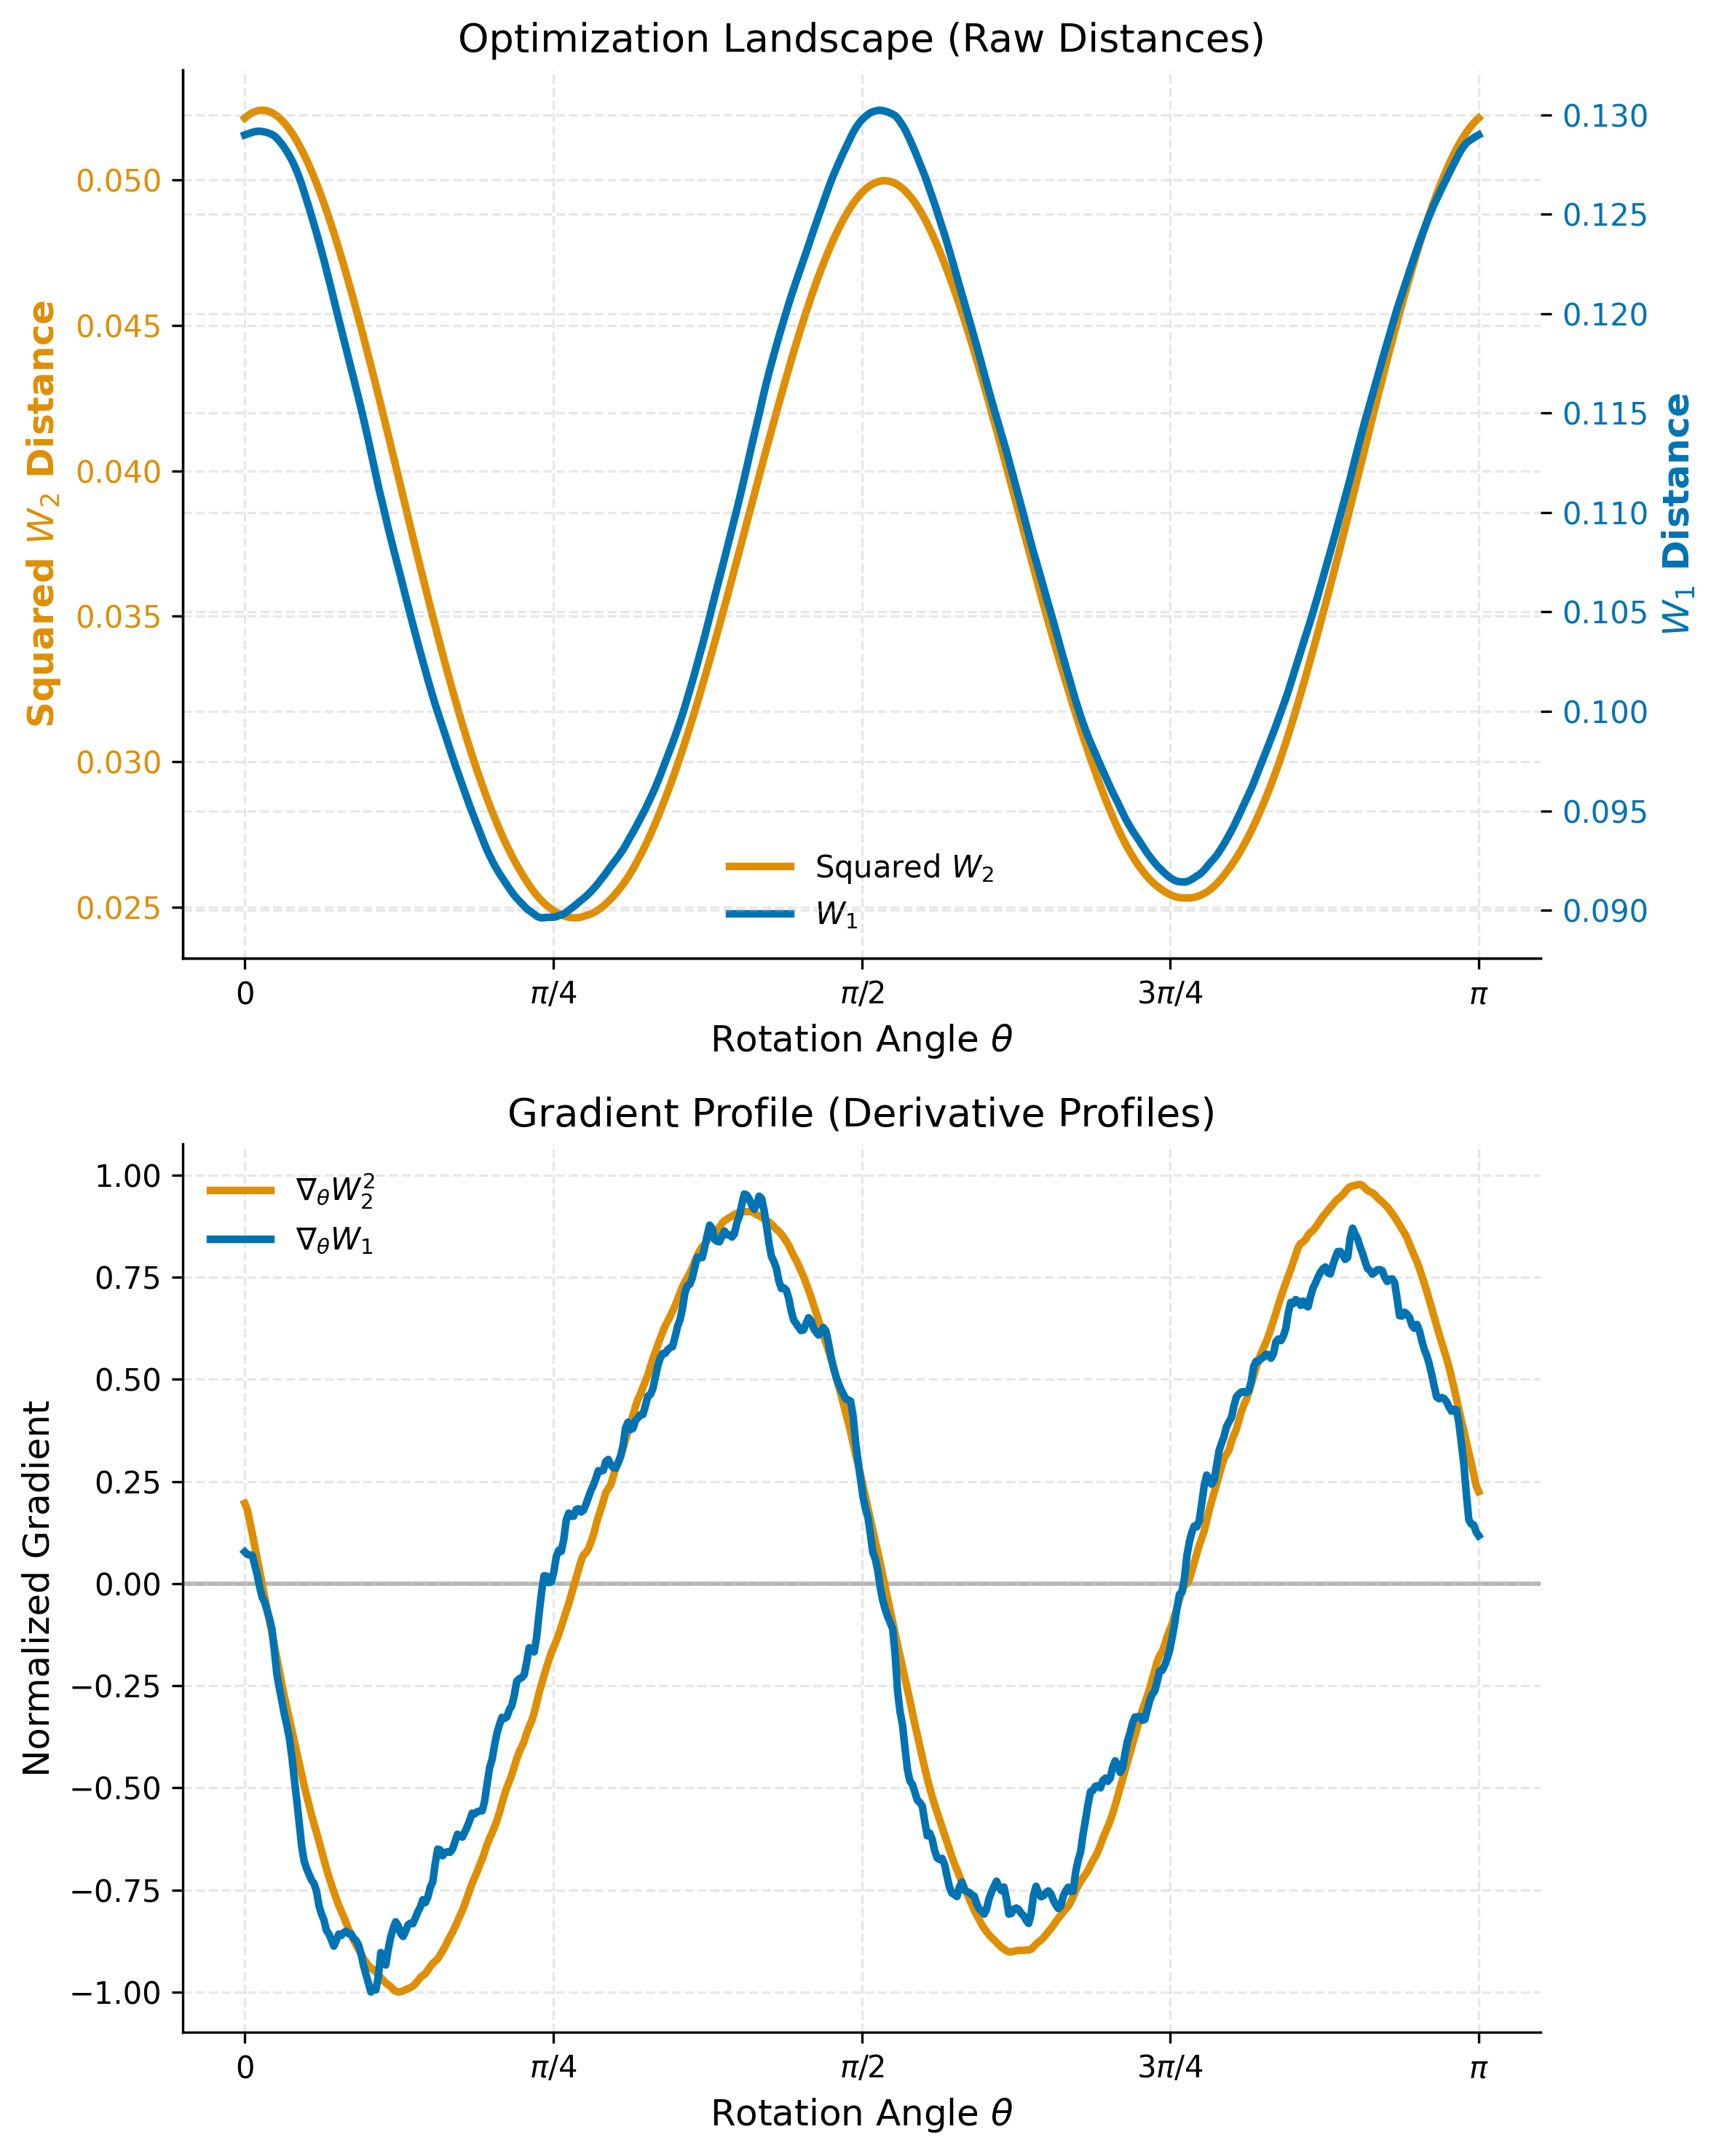

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), dpi=300)

# --- Panel 1: Raw Objective Landscape ---
ax1.plot(thetas_np, w2_sq_raw, label='Squared $W_2$', color='#DE8F05', linewidth=2.5)
ax1.set_xlabel(r'Rotation Angle $\theta$')
ax1.set_ylabel('Squared $W_2$ Distance', color='#DE8F05', weight='bold')
ax1.tick_params(axis='y', labelcolor='#DE8F05')
ax1.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax1.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax1.set_title('Optimization Landscape (Raw Distances)')

ax1_twin = ax1.twinx()
ax1_twin.plot(thetas_np, w1_raw, label='$W_1$', color='#0173B2', linewidth=2.5)
ax1_twin.set_ylabel('$W_1$ Distance', color='#0173B2', weight='bold')
ax1_twin.tick_params(axis='y', labelcolor='#0173B2')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center')

# --- Panel 2: Gradient Profile ---
ax2.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)
ax2.plot(thetas_np, grad_w2_norm, label=r'$\nabla_\theta W_2^2$', color='#DE8F05', linewidth=2.5)
ax2.plot(thetas_np, grad_w1_norm, label=r'$\nabla_\theta W_1$', color='#0173B2', linewidth=2.5)
ax2.set_xlabel(r'Rotation Angle $\theta$')
ax2.set_ylabel('Normalized Gradient')
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax2.set_title('Gradient Profile (Derivative Profiles)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()